# Autoencoder V2 — Quality-Focused CASIA Training on Colab

This notebook retrains/fine-tunes the **existing validated convolutional Autoencoder**; it does not change the architecture, 24× bottleneck, dataset split, or `[0,1]` preprocessing.

Recommended strategy: initialize from `best_autoencoder.pth` (epoch 42 baseline), then fine-tune with a lower learning rate. The new run writes only `*_v2` artifacts, so the baseline remains recoverable. Better results are selected strictly by validation MSE—improvement is targeted, not guaranteed.

## 1. Colab setup
Select **Runtime → Change runtime type → T4 GPU** before running.

In [1]:
%pip install -q kagglehub Pillow matplotlib numpy pandas scikit-image scikit-learn

In [2]:
import os, sys, json, csv, shutil, subprocess, importlib
from pathlib import Path, PureWindowsPath
import torch

assert torch.cuda.is_available(), "Enable a GPU runtime: Runtime > Change runtime type > T4 GPU"
GPU_NAME = torch.cuda.get_device_name(0)
print("CUDA:", torch.cuda.is_available())
print("GPU:", GPU_NAME)

CUDA: True
GPU: Tesla T4


## 2. Obtain project code
The CASIA images and trained weights are not uploaded to GitHub.

In [3]:
REPO_URL = "https://github.com/chetanraje27/Digital-Evidence-GenAI.git"
PROJECT_ROOT = Path("/content/Digital-Evidence-GenAI")
if not PROJECT_ROOT.exists():
    subprocess.run(["git", "clone", REPO_URL, str(PROJECT_ROOT)], check=True)
else:
    subprocess.run(["git", "-C", str(PROJECT_ROOT), "pull", "--ff-only"], check=True)
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Project:", PROJECT_ROOT)

Project: /content/Digital-Evidence-GenAI


## 3. Download CASIA v2.0 and validate paths
The committed manifests remain the source of truth. Ground-truth PNG masks are excluded.

In [4]:
import kagglehub

RAW_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)
downloaded = None
if not (RAW_DIR / "CASIA2" / "Au").is_dir():
    downloaded = Path(kagglehub.dataset_download(
        "divg07/casia-20-image-tampering-detection-dataset", output_dir=str(RAW_DIR)
    )).resolve()
    print("Downloaded to:", downloaded)

# KaggleHub may ignore output_dir when it reuses Colab's mounted cache and
# return /kaggle/input/... instead. Search the returned path, not only RAW_DIR.
if not (RAW_DIR / "CASIA2").is_dir():
    search_roots = [p for p in (downloaded, RAW_DIR) if p is not None and p.exists()]
    candidates = []
    for root in search_roots:
        # Handle both a returned CASIA2 directory and a parent containing it.
        if root.name.casefold() == "casia2" and (root / "Au").is_dir() and (root / "Tp").is_dir():
            candidates.append(root)
        candidates.extend(
            p for p in root.rglob("CASIA2")
            if (p / "Au").is_dir() and (p / "Tp").is_dir()
        )
    assert candidates, (
        f"CASIA2/Au and CASIA2/Tp were not found under: {search_roots}. "
        "Inspect the printed Kaggle dataset location."
    )
    source_casia2 = candidates[0].resolve()
    os.symlink(source_casia2, RAW_DIR / "CASIA2", target_is_directory=True)
    print("Linked:", RAW_DIR / "CASIA2", "->", source_casia2)

SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
rows_by_split = {}
for name in ("train", "validation", "test"):
    with (SPLITS_DIR / f"{name}.csv").open(newline="", encoding="utf-8") as f:
        rows_by_split[name] = list(csv.DictReader(f))
all_rows = sum(rows_by_split.values(), [])
paths = [row["image_path"] for row in all_rows]
assert {name: len(rows) for name, rows in rows_by_split.items()} == {"train": 8830, "validation": 1892, "test": 1892}
assert len(paths) == len(set(p.casefold() for p in paths)) == 12614
assert all(not Path(p).is_absolute() and not PureWindowsPath(p).is_absolute() for p in paths)
assert all(Path(p).suffix.lower() != ".png" and "groundtruth" not in p.lower() for p in paths)
missing = [p for p in paths if not (PROJECT_ROOT / p).is_file()]
assert not missing, f"Missing images, first examples: {missing[:5]}"
print("Split and leakage validation: PASS", {k: len(v) for k, v in rows_by_split.items()})

100%|██████████| 2.56G/2.56G [02:11<00:00, 20.8MB/s]

Extracting files...


Downloaded to: /content/Digital-Evidence-GenAI/data/raw
Split and leakage validation: PASS {'train': 8830, 'validation': 1892, 'test': 1892}


## 4. Validate pipeline and architecture

In [5]:
from ae_dataset import create_ae_dataloaders
from autoencoder import ConvolutionalAutoencoder

loaders = create_ae_dataloaders(SPLITS_DIR, image_size=128, batch_size=32, num_workers=2, seed=42)
batch = next(iter(loaders["train"]))["image"]
model = ConvolutionalAutoencoder()
with torch.inference_mode():
    latent = model.encode(batch[:2])
    output = model(batch[:2])
assert batch.shape == (32, 3, 128, 128)
assert latent.shape == (2, 32, 8, 8) and output.shape == (2, 3, 128, 128)
assert 0 <= batch.min() <= batch.max() <= 1
print("Batch:", tuple(batch.shape), "range:", (float(batch.min()), float(batch.max())))
print("Latent:", tuple(latent.shape), "parameters:", sum(p.numel() for p in model.parameters()), "compression: 24x")

Batch: (32, 3, 128, 128) range: (0.0, 1.0)
Latent: (2, 32, 8, 8) parameters: 265571 compression: 24x


## 5. Baseline checkpoint

Recommended: place the existing `best_autoencoder.pth` in Google Drive at `/content/drive/MyDrive/Digital_Evidence/checkpoints/`. If it is absent, the notebook can train from scratch, but fine-tuning the validated baseline is the safer route to improving its result.

In [6]:
from google.colab import drive
drive.mount("/content/drive")

DRIVE_PROJECT = Path("/content/drive/MyDrive/Digital_Evidence")
DRIVE_PROJECT.mkdir(parents=True, exist_ok=True)
baseline_candidates = [
    DRIVE_PROJECT / "checkpoints" / "best_autoencoder.pth",
    PROJECT_ROOT / "checkpoints" / "best_autoencoder.pth",
]
BASELINE_CHECKPOINT = next((p for p in baseline_candidates if p.is_file()), None)
print("Baseline checkpoint:", BASELINE_CHECKPOINT or "NOT FOUND — scratch training will be used")
if BASELINE_CHECKPOINT:
    ckpt = torch.load(BASELINE_CHECKPOINT, map_location="cpu", weights_only=True)
    print("Baseline epoch:", ckpt.get("epoch"), "validation MSE:", ckpt.get("validation_loss"))

Mounted at /content/drive
Baseline checkpoint: /content/Digital-Evidence-GenAI/checkpoints/best_autoencoder.pth
Baseline epoch: 42 validation MSE: 0.00355496878162751


## 6. Quality-focused configuration

- Existing architecture, 128×128 input, batch size 32, Adam, and MSE remain unchanged.
- Fine-tuning starts at `1e-4`; `ReduceLROnPlateau` can reduce it to `1e-6`.
- Up to 60 additional epochs; early stopping patience 10.
- CUDA mixed precision improves T4 speed without changing the model.

In [7]:
from argparse import Namespace

V2_ROOT = PROJECT_ROOT
common = dict(
    splits_dir=SPLITS_DIR, image_size=128, batch_size=32, num_workers=2,
    learning_rate=1e-4 if BASELINE_CHECKPOINT else 1e-3,
    min_learning_rate=1e-6, weight_decay=1e-6, max_epochs=60,
    patience=10, lr_patience=3, lr_factor=0.5, min_delta=1e-7,
    seed=42, initial_checkpoint=BASELINE_CHECKPOINT,
)
TRAIN_ARGS = Namespace(**common,
    checkpoint_path=V2_ROOT / "checkpoints" / "best_autoencoder_v2.pth",
    history_path=V2_ROOT / "results" / "ae_v2_training_history.csv",
    summary_path=V2_ROOT / "results" / "ae_v2_training_summary.json",
    curve_path=V2_ROOT / "outputs" / "ae_v2" / "training_curve.png",
    grid_path=V2_ROOT / "outputs" / "ae_v2" / "reconstruction_grid.png",
    smoke_test=False, smoke_batches=2, require_cuda=True,
)
print(vars(TRAIN_ARGS))

{'splits_dir': PosixPath('/content/Digital-Evidence-GenAI/data/splits'), 'image_size': 128, 'batch_size': 32, 'num_workers': 2, 'learning_rate': 0.0001, 'min_learning_rate': 1e-06, 'weight_decay': 1e-06, 'max_epochs': 60, 'patience': 10, 'lr_patience': 3, 'lr_factor': 0.5, 'min_delta': 1e-07, 'seed': 42, 'initial_checkpoint': PosixPath('/content/Digital-Evidence-GenAI/checkpoints/best_autoencoder.pth'), 'checkpoint_path': PosixPath('/content/Digital-Evidence-GenAI/checkpoints/best_autoencoder_v2.pth'), 'history_path': PosixPath('/content/Digital-Evidence-GenAI/results/ae_v2_training_history.csv'), 'summary_path': PosixPath('/content/Digital-Evidence-GenAI/results/ae_v2_training_summary.json'), 'curve_path': PosixPath('/content/Digital-Evidence-GenAI/outputs/ae_v2/training_curve.png'), 'grid_path': PosixPath('/content/Digital-Evidence-GenAI/outputs/ae_v2/reconstruction_grid.png'), 'smoke_test': False, 'smoke_batches': 2, 'require_cuda': True}


## 7. Required smoke test
This uses two train/validation batches and writes temporary artifacts only.

In [8]:
import train_autoencoder_v2
importlib.reload(train_autoencoder_v2)

smoke_dir = Path("/content/ae_v2_smoke")
SMOKE_ARGS = Namespace(**{**vars(TRAIN_ARGS),
    "checkpoint_path": smoke_dir / "smoke.pth", "history_path": smoke_dir / "history.csv",
    "summary_path": smoke_dir / "summary.json", "curve_path": smoke_dir / "curve.png",
    "grid_path": smoke_dir / "grid.png", "smoke_test": True, "require_cuda": True,
})
smoke_summary = train_autoencoder_v2.train(SMOKE_ARGS)
assert smoke_summary["epochs_completed"] == 1
print("Smoke test: PASS", smoke_summary)

Epoch 001/001 | train=0.00384554 | validation=0.00289335 | lr=1.00e-04 | seconds=2.8


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL pathlib._local.PosixPath was not an allowed global by default. Please use `torch.serialization.add_safe_globals([pathlib._local.PosixPath])` or the `torch.serialization.safe_globals([pathlib._local.PosixPath])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about type

## 8. Full GPU training
Set `RUN_FULL_TRAINING = True`. The best validation checkpoint is saved, not merely the final epoch.

In [9]:
RUN_FULL_TRAINING = True
if RUN_FULL_TRAINING:
    training_summary = train_autoencoder_v2.train(TRAIN_ARGS)
    print(json.dumps(training_summary, indent=2))
else:
    print("Full training skipped.")

Epoch 001/060 | train=0.00355012 | validation=0.00349725 | lr=1.00e-04 | seconds=28.2
Epoch 002/060 | train=0.00353503 | validation=0.00349380 | lr=1.00e-04 | seconds=28.0
Epoch 003/060 | train=0.00353219 | validation=0.00349078 | lr=1.00e-04 | seconds=27.0
Epoch 004/060 | train=0.00352882 | validation=0.00348850 | lr=1.00e-04 | seconds=26.4
Epoch 005/060 | train=0.00352637 | validation=0.00348439 | lr=1.00e-04 | seconds=26.5
Epoch 006/060 | train=0.00352372 | validation=0.00348399 | lr=1.00e-04 | seconds=24.9
Epoch 007/060 | train=0.00352185 | validation=0.00348054 | lr=1.00e-04 | seconds=26.5
Epoch 008/060 | train=0.00351968 | validation=0.00347796 | lr=1.00e-04 | seconds=26.6
Epoch 009/060 | train=0.00351689 | validation=0.00347694 | lr=1.00e-04 | seconds=26.7
Epoch 010/060 | train=0.00351509 | validation=0.00347560 | lr=1.00e-04 | seconds=26.9
Epoch 011/060 | train=0.00351337 | validation=0.00347260 | lr=1.00e-04 | seconds=25.1
Epoch 012/060 | train=0.00351006 | validation=0.003468

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL pathlib._local.PosixPath was not an allowed global by default. Please use `torch.serialization.add_safe_globals([pathlib._local.PosixPath])` or the `torch.serialization.safe_globals([pathlib._local.PosixPath])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about type

## 9. Training curves and best checkpoint

,epoch,train_loss,validation_loss,learning_rate,epoch_time_seconds
55,56,0.003435,0.003400,0.0001,26.709387
56,57,0.003435,0.003398,0.0001,26.882411
57,58,0.003433,0.003397,0.0001,26.849827
58,59,0.003432,0.003395,0.0001,25.879255
59,60,0.003430,0.003393,0.0001,26.002253


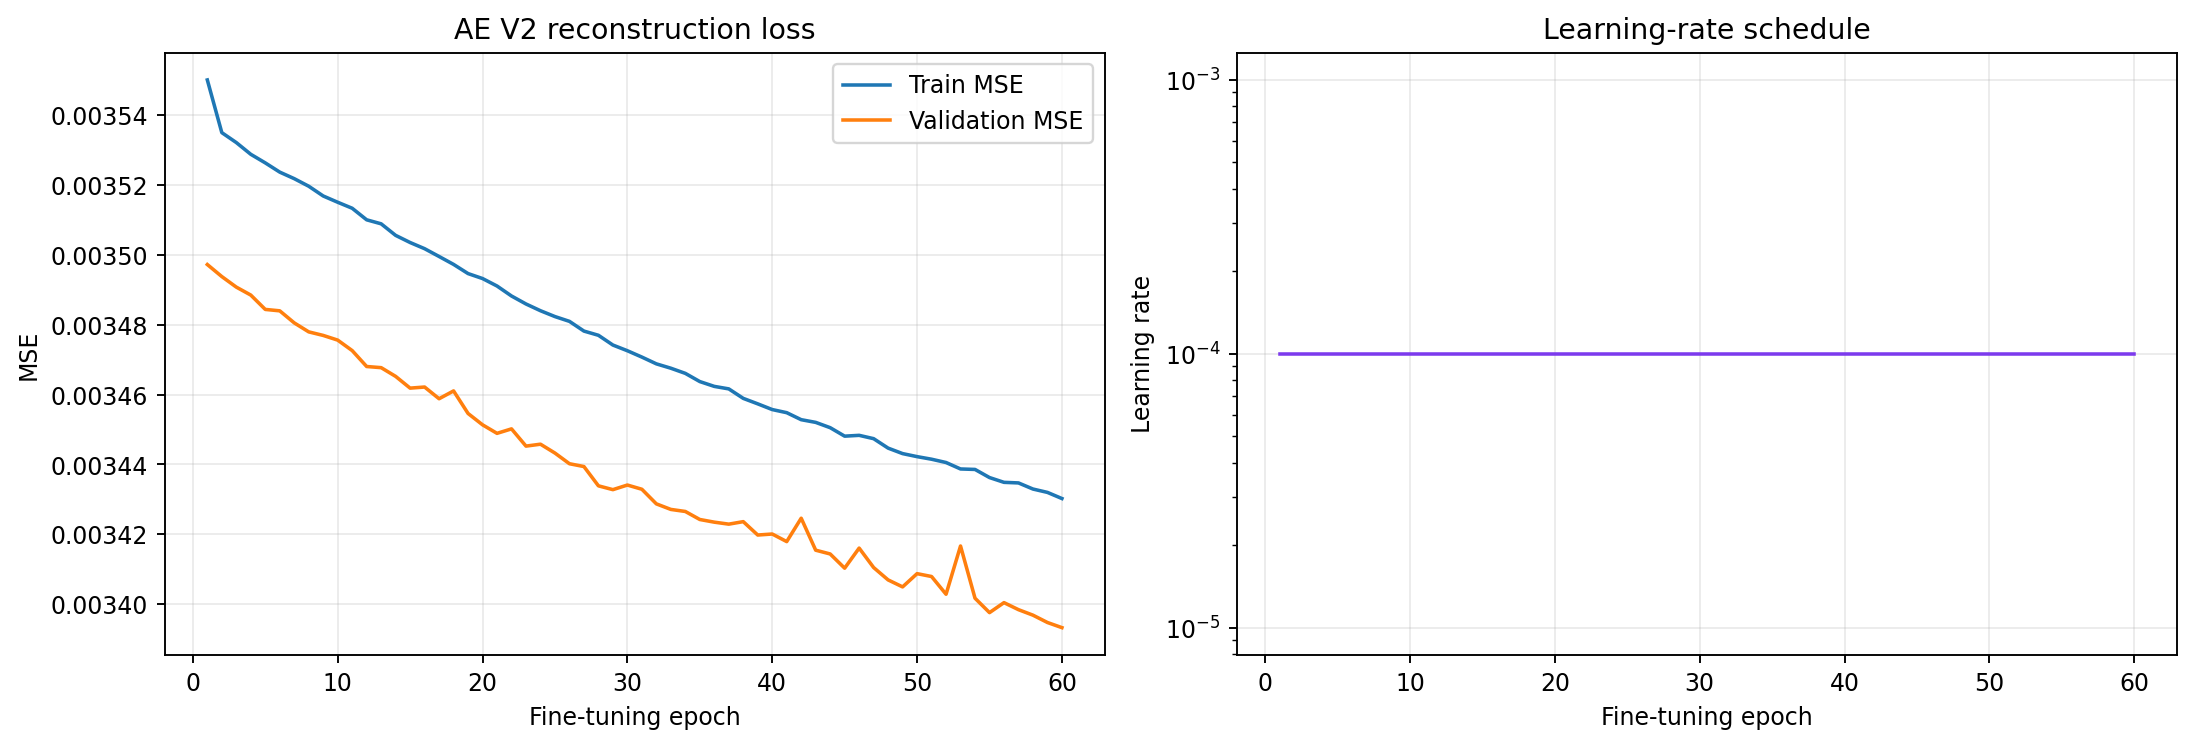

FileNotFoundError: [Errno 2] No such file or directory: '/content/Digital-Evidence-GenAI/outputs/ae_v2/reconstruction_grid.png'

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image as DisplayImage

history = pd.read_csv(TRAIN_ARGS.history_path)
display(history.tail())
display(DisplayImage(filename=str(TRAIN_ARGS.curve_path)))
display(DisplayImage(filename=str(TRAIN_ARGS.grid_path)))
best = torch.load(TRAIN_ARGS.checkpoint_path, map_location="cpu", weights_only=True)
print("Best fine-tuning epoch:", best.get("epoch"))
print("Best validation MSE:", best.get("validation_loss"))

## 10. Complete held-out test evaluation
Evaluation uses all 1,892 test images and reports per-image MSE, PSNR, and SSIM.

In [11]:
from evaluate_autoencoder import evaluate

EVAL_ARGS = Namespace(
    splits_dir=SPLITS_DIR, checkpoint_path=TRAIN_ARGS.checkpoint_path,
    per_image_csv=PROJECT_ROOT / "results" / "ae_v2_test_per_image_metrics.csv",
    metrics_json=PROJECT_ROOT / "results" / "ae_v2_test_metrics.json",
    reconstruction_grid=PROJECT_ROOT / "outputs" / "ae_v2" / "test_reconstruction_grid.png",
    mse_plot=PROJECT_ROOT / "outputs" / "ae_v2" / "authentic_vs_tampered_mse.png",
    ssim_plot=PROJECT_ROOT / "outputs" / "ae_v2" / "authentic_vs_tampered_ssim.png",
    image_size=128, batch_size=32, num_workers=2, samples_per_class=3, seed=42,
)
test_metrics = evaluate(EVAL_ARGS)
print(json.dumps(test_metrics, indent=2))

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL pathlib._local.PosixPath was not an allowed global by default. Please use `torch.serialization.add_safe_globals([pathlib._local.PosixPath])` or the `torch.serialization.safe_globals([pathlib._local.PosixPath])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about type

## 11. Visual test results and baseline comparison

In [12]:
display(DisplayImage(filename=str(EVAL_ARGS.reconstruction_grid)))
display(DisplayImage(filename=str(EVAL_ARGS.mse_plot)))

baseline_metrics_path = PROJECT_ROOT / "results" / "ae_test_metrics.json"
if baseline_metrics_path.is_file():
    baseline_metrics = json.loads(baseline_metrics_path.read_text())
    comparison = pd.DataFrame([
        {"model": "Current baseline", **{m: baseline_metrics["overall"][f"{m}_mean"] for m in ("mse", "psnr", "ssim")}},
        {"model": "New AE V2", **{m: test_metrics["overall"][f"{m}_mean"] for m in ("mse", "psnr", "ssim")}},
    ])
    display(comparison)
    print("V2 improved MSE:", comparison.loc[1, "mse"] < comparison.loc[0, "mse"])
else:
    print("Baseline metrics file unavailable; V2 metrics are shown above.")
print("Note: authentic/tampered reconstruction differences are exploratory; the AE is not a forgery detector.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Digital-Evidence-GenAI/outputs/ae_v2/test_reconstruction_grid.png'

## 12. Persist V2 artifacts to Google Drive

In [13]:
artifact_paths = [
    TRAIN_ARGS.checkpoint_path, TRAIN_ARGS.history_path, TRAIN_ARGS.summary_path,
    TRAIN_ARGS.curve_path, TRAIN_ARGS.grid_path, EVAL_ARGS.per_image_csv,
    EVAL_ARGS.metrics_json, EVAL_ARGS.reconstruction_grid, EVAL_ARGS.mse_plot, EVAL_ARGS.ssim_plot,
]
for source in artifact_paths:
    relative = source.relative_to(PROJECT_ROOT)
    destination = DRIVE_PROJECT / relative
    destination.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(source, destination)
    print("Saved:", destination)

Saved: /content/drive/MyDrive/Digital_Evidence/checkpoints/best_autoencoder_v2.pth
Saved: /content/drive/MyDrive/Digital_Evidence/results/ae_v2_training_history.csv


FileNotFoundError: [Errno 2] No such file or directory: '/content/Digital-Evidence-GenAI/results/ae_v2_training_summary.json'

## 13. Final report

In [14]:
print("GPU:", GPU_NAME)
print("Epochs completed:", training_summary["epochs_completed"])
print("Best fine-tuning epoch:", training_summary["best_epoch"])
print("Best validation MSE:", training_summary["best_validation_loss"])
print("Test MSE:", test_metrics["overall"]["mse_mean"])
print("Test PSNR:", test_metrics["overall"]["psnr_mean"])
print("Test SSIM:", test_metrics["overall"]["ssim_mean"])
print("Early stopping:", training_summary["early_stopping_triggered"])
print("Training seconds:", training_summary["training_time_seconds"])
print("Checkpoint:", TRAIN_ARGS.checkpoint_path)

GPU: Tesla T4


NameError: name 'training_summary' is not defined